# 📊 Fundamental Analysis Report v2
## 미국 주식 투자전략 — FCFF + Relative Valuation 기반 매수 후보 선정

| 셀 | 역할 |
|----|---------|
| 1  | 경로 자동 감지 (노트북 / 데스크탑) |
| 2  | Import & DB 연결 |
| **3**  | **파라미터 설정 ← 여기만 수정** |
| 4  | DB 데이터 로드 (FCFF / Relative / Revenue) |
| 5  | 종합 Valuation 테이블 계산 (가중 적정주가) |
| **6**  | **매수 후보 선정 (Upside 기준 + 최소 20개 보장)** |
| 7  | 시각화 — Upside 순위 차트 |
| 8  | Excel 보고서 저장 |

### 선정 로직
```
① 전체 Valuation 대상 : FCFF 60% + Relative 40% 가중 적정주가 계산
② 1차 후보 (Upside 기준 충족)
      대형주 (시총 > 10B)  : upside ≥ 30%
      중소형주 (시총 ≤ 10B): upside ≥ 40%
③ 1차 후보 < 10개 → 기준 미충족 종목을 upside 순으로 보충 → 최소 20개 확보
④ 상위 20개 최종 추천 (upside 내림차순)
```


## Cell 1 · 경로 자동 감지

In [10]:
import sys, os, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

# ── 후보 루트 (노트북 / 데스크탑) ────────────────────────────
_CANDIDATE_ROOTS = [
    r'C:\Users\Hoyoung_Park\PyCharmMiscProject\stock_forecast',
    r'C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy',
]

def _setup_path() -> str:
    try:
        start = Path(__file__).resolve().parent
    except NameError:
        start = Path.cwd()
    for p in [start] + list(start.parents):
        if (p / 'DATA').is_dir():
            root = str(p)
            if root not in sys.path:
                sys.path.insert(0, root)
            print(f'[PATH] 자동 감지 성공 : {root}')
            return root
    for candidate in _CANDIDATE_ROOTS:
        if os.path.isdir(candidate) and os.path.isdir(os.path.join(candidate, 'DATA')):
            if candidate not in sys.path:
                sys.path.insert(0, candidate)
            print(f'[PATH] 후보 경로 사용 : {candidate}')
            return candidate
    raise EnvironmentError(
        'DATA 폴더를 찾을 수 없습니다.\n'
        '_CANDIDATE_ROOTS 를 현재 환경에 맞게 수정하세요.'
    )

_ROOT = _setup_path()
print(f'[확인] 프로젝트 루트 : {_ROOT}')
print(f'[확인] DATA 경로    : {os.path.join(_ROOT, "DATA")}')

[PATH] 자동 감지 성공 : C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy
[확인] 프로젝트 루트 : C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy
[확인] DATA 경로    : C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\DATA


## Cell 2 · Import & DB 연결

In [11]:
import gc, math, warnings
from datetime import datetime, timedelta
from typing import Optional, List, Dict

import numpy as np
import pandas as pd
import pymysql
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display
from sqlalchemy import text

matplotlib.rcParams['font.family']        = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['figure.dpi']         = 110

# ── 내부 모듈 ────────────────────────────────────────────────
from DATA.config import get_db_info, get_engine

# ── Screened Ticker List ──────────────────────────────────────
# 분석 대상을 us_target_ticker_list_screened_20260411.py 의
# ticker_list (1026개) 로 엄격히 한정합니다.
# 해외기업(ADR), 에너지, REIT, 초소형주(< 1B) 는 이미 제외된 리스트입니다.
#
# 파일 위치: DATA 폴더 (config.py 와 동일 폴더)
#   노트북 : C:\Users\Hoyoung_Park\PyCharmMiscProject\stock_forecast\DATA\
#   데스크탑: C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\DATA\
# ─────────────────────────────────────────────────────────────
try:
    # ① 고정 파일명으로 직접 import (가장 안전)
    from DATA.us_target_ticker_list_screened_20260411 import (
        ticker_list       as US_TICKER_LIST,
        ticker_sector_map as US_SECTOR_MAP,
    )
    _src = 'us_target_ticker_list_screened_20260411.py'

except ImportError:
    # ② 파일명이 다를 경우 DATA 폴더에서 screened 파일 자동 탐색
    import glob, importlib.util
    _candidates = sorted(
        glob.glob(os.path.join(_ROOT, 'DATA', 'us_target_ticker_list_screened*.py'))
    )
    if not _candidates:
        raise FileNotFoundError(
            'DATA 폴더에 us_target_ticker_list_screened_*.py 파일이 없습니다.\n'
            '첨부된 us_target_ticker_list_screened_20260411.py 를 DATA 폴더에 복사하세요.'
        )
    _spec = importlib.util.spec_from_file_location('ticker_mod', _candidates[-1])
    _mod  = importlib.util.module_from_spec(_spec)
    _spec.loader.exec_module(_mod)
    US_TICKER_LIST = _mod.ticker_list
    US_SECTOR_MAP  = getattr(_mod, 'ticker_sector_map', {})
    _src = os.path.basename(_candidates[-1])

# ── 로드 결과 확인 ────────────────────────────────────────────
print('=' * 55)
print(f'  [Ticker List] 로드 완료')
print(f'  파일     : {_src}')
print(f'  종목 수  : {len(US_TICKER_LIST)}개')
print(f'  섹터 맵  : {len(US_SECTOR_MAP)}개')
print()

# 섹터 분포 간략 출력
from collections import Counter
_sector_cnt = Counter(v.get('sector','N/A') for v in US_SECTOR_MAP.values())
print('  [섹터 분포]')
for _sec, _cnt in sorted(_sector_cnt.items(), key=lambda x: -x[1]):
    print(f'    {_sec:<30} : {_cnt:>4}개')
print('=' * 55)

# ── DB 연결 ──────────────────────────────────────────────────
db_info = get_db_info()
engine  = get_engine(db_info)

def get_conn():
    return pymysql.connect(
        host       = db_info['host'],
        port       = int(db_info.get('port', 3307)),
        user       = db_info['user'],
        password   = db_info['password'],
        db         = db_info.get('database', 'investar'),
        charset    = 'utf8mb4',
        autocommit = False,
        cursorclass= pymysql.cursors.DictCursor,
    )

try:
    with engine.connect() as c:
        c.execute(text('SELECT 1'))
    print(f'[OK] DB 연결 성공  host={db_info["host"]}:{db_info["port"]}')
except Exception as e:
    print(f'[FAIL] DB 연결 실패: {e}')


  [Ticker List] 로드 완료
  파일     : us_target_ticker_list_screened_20260411.py
  종목 수  : 1026개
  섹터 맵  : 1026개

  [섹터 분포]
    Industrials                    :  263개
    Technology                     :  208개
    Healthcare                     :  185개
    Consumer Cyclical              :  182개
    Consumer Defensive             :   78개
    Basic Materials                :   72개
    Communication Services         :   37개
    Financial Services             :    1개
[OK] DB 연결 성공  host=192.168.0.230:3307


## Cell 3 · 파라미터 설정  ← 여기만 수정

> 가중치, Upside 기준, 보장 종목 수를 이 셀에서 조정합니다.

In [12]:
# ══════════════════════════════════════════════════════════════
#  분석 파라미터 — 여기만 수정하세요
# ══════════════════════════════════════════════════════════════

EVAL_DATE     = datetime.today().strftime('%Y-%m-%d')
REVENUE_MODEL = 'Ensemble'   # SARIMA / ETS / Prophet / LSTM / Theta / Ensemble
REVENUE_ITEM  = 'sale'

# ── Valuation 가중치 ─────────────────────────────────────────
W_FCFF = 0.60    # FCFF DCF 비중
W_RELV = 0.40    # Relative Valuation 비중

# ── Upside 상한 캡 (비정상 이상치 제거) ──────────────────────
#   FCFF 또는 Relative 모형 오류로 과도하게 높은 적정주가가
#   산출되는 경우를 차단합니다.
#
#   UPSIDE_CAP  = 150.0  →  현재가 대비 +150% 초과 종목 제외
#                            (현재가의 2.5배 이상 적정주가 = 모형 오류 의심)
#   0 이하로 설정하면 캡 비활성화
UPSIDE_CAP = 150.0

# ── 1차 매수 후보 Upside 최소 기준 ───────────────────────────
UPSIDE_LARGE_CAP = 0.30    # 대형주  (시총 > 10B USD) : 30% 이상
UPSIDE_SMALL_CAP = 0.40    # 중소형주 (시총 ≤ 10B USD): 40% 이상
SMALL_CAP_THRESH = 10.0    # 중소형주 기준 시총 (B USD)

# ── 최종 추천 종목 수 설정 ────────────────────────────────────
TARGET_PICKS = 50    # 목표 추천 종목 수
MIN_PICKS    = 20    # 이 수 미만이면 보충 로직 발동

# ── DB 테이블명 ──────────────────────────────────────────────
TBL_REVENUE = 'us_revenue_forecast_data'
TBL_FCFF    = 'us_fcff_dcf_valuation'
TBL_RELV    = 'us_relative_valuation'

# ── 결과 Excel 저장 경로 ─────────────────────────────────────
REPORT_DIR  = os.path.join(_ROOT, 'reports')
os.makedirs(REPORT_DIR, exist_ok=True)
REPORT_FILE = os.path.join(REPORT_DIR, f'fundamental_report_{EVAL_DATE}.xlsx')

print('=' * 60)
print(f'  평가일          : {EVAL_DATE}')
print(f'  FCFF 비중       : {W_FCFF*100:.0f}%   /  Relative 비중 : {W_RELV*100:.0f}%')
print(f'  Upside 상한 캡  : +{UPSIDE_CAP:.0f}%  ← 이 값 초과 종목은 모형 오류로 간주해 제외')
print(f'  Upside 최소     : 대형주 +{UPSIDE_LARGE_CAP*100:.0f}%  /  중소형주 +{UPSIDE_SMALL_CAP*100:.0f}%')
print(f'  목표 추천 수    : {TARGET_PICKS}개  (최소 기준: {MIN_PICKS}개 미만 시 보충)')
print(f'  리포트 경로     : {REPORT_FILE}')
print('=' * 60)


  평가일          : 2026-04-13
  FCFF 비중       : 60%   /  Relative 비중 : 40%
  Upside 상한 캡  : +150%  ← 이 값 초과 종목은 모형 오류로 간주해 제외
  Upside 최소     : 대형주 +30%  /  중소형주 +40%
  목표 추천 수    : 50개  (최소 기준: 20개 미만 시 보충)
  리포트 경로     : C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\reports\fundamental_report_2026-04-13.xlsx


## Cell 4 · DB 데이터 로드

In [13]:
# ──────────────────────────────────────────────────────────────
# 4-1. FCFF DCF — ticker당 정확히 1개 row 추출
#
# [중복 발생 원인]
#   us_fcff_dcf_valuation 의 unique key = (ticker, date, quarter)
#   → 동일 ticker + 동일 date 에 quarter 별 여러 row 존재
#   → MAX(date) 만으로는 중복 제거 불가
#
# [해결 방법]
#   ① quarter IS NULL/'' 인 summary row 우선 (최신 date 기준)
#   ② summary row 없으면 MAX(id) → ticker당 무조건 1 row
#   ③ 최후 안전망: groupby('ticker').last() 로 Python 레벨 중복 제거
# ──────────────────────────────────────────────────────────────
def load_fcff(tickers: List[str]) -> pd.DataFrame:
    ticker_str = "','".join(tickers)

    # 시도 1: quarter 없는 summary row (최신 date 기준)
    sql_summary = (
        f"SELECT f.* FROM {TBL_FCFF} f "
        f"INNER JOIN ("
        f"  SELECT ticker, MAX(date) AS max_date "
        f"  FROM {TBL_FCFF} "
        f"  WHERE ticker IN ('{ticker_str}') "
        f"    AND (quarter IS NULL OR quarter = '') "
        f"  GROUP BY ticker "
        f") m ON f.ticker = m.ticker AND f.date = m.max_date "
        f"WHERE (f.quarter IS NULL OR f.quarter = '')"
    )

    # 시도 2: MAX(id) — ticker당 무조건 1 row
    sql_maxid = (
        f"SELECT f.* FROM {TBL_FCFF} f "
        f"INNER JOIN ("
        f"  SELECT ticker, MAX(id) AS max_id "
        f"  FROM {TBL_FCFF} "
        f"  WHERE ticker IN ('{ticker_str}') "
        f"  GROUP BY ticker "
        f") m ON f.id = m.max_id"
    )

    conn = get_conn()
    try:
        with conn.cursor() as cur:
            # summary row 먼저 시도
            try:
                cur.execute(sql_summary)
                rows = cur.fetchall()
            except Exception:
                rows = []
            if rows:
                df = pd.DataFrame(rows)
            else:
                # summary row 없으면 MAX(id)
                cur.execute(sql_maxid)
                rows = cur.fetchall()
                df = pd.DataFrame(rows)
        # 최후 안전망: Python 레벨 중복 제거
        if not df.empty and df['ticker'].duplicated().any():
            sort_col = 'id' if 'id' in df.columns else df.columns[0]
            df = (df.sort_values(sort_col)
                    .groupby('ticker', as_index=False).last()
                    .reset_index(drop=True))
        # ── [FIX] DB DECIMAL 타입 → float64 변환 (tp_weighted 계산 오류 방지)
        for col in df.select_dtypes(include='object').columns:
            if col != 'ticker':
                df[col] = pd.to_numeric(df[col], errors='ignore')
        return df
    finally:
        conn.close()


# ──────────────────────────────────────────────────────────────
# 4-2. Relative Valuation — ticker당 정확히 1개 row 추출
#   unique key = (ticker, date) 이지만, MAX(id) 로 완전 보장
# ──────────────────────────────────────────────────────────────
def load_relv(tickers: List[str]) -> pd.DataFrame:
    ticker_str = "','".join(tickers)

    sql = (
        f"SELECT r.* FROM {TBL_RELV} r "
        f"INNER JOIN ("
        f"  SELECT ticker, MAX(id) AS max_id "
        f"  FROM {TBL_RELV} "
        f"  WHERE ticker IN ('{ticker_str}') "
        f"  GROUP BY ticker "
        f") m ON r.id = m.max_id"
    )

    conn = get_conn()
    try:
        with conn.cursor() as cur:
            cur.execute(sql)
            rows = cur.fetchall()
        df = pd.DataFrame(rows)
        # 안전망
        if not df.empty and df['ticker'].duplicated().any():
            sort_col = 'id' if 'id' in df.columns else df.columns[0]
            df = (df.sort_values(sort_col)
                    .groupby('ticker', as_index=False).last()
                    .reset_index(drop=True))
        # ── [FIX] DB DECIMAL 타입 → float64 변환 (tp_weighted 계산 오류 방지)
        for col in df.select_dtypes(include='object').columns:
            if col != 'ticker':
                df[col] = pd.to_numeric(df[col], errors='ignore')
        return df
    finally:
        conn.close()


# ──────────────────────────────────────────────────────────────
# 4-3. Revenue Forecast — 4Q / 8Q 성장률 계산
# ──────────────────────────────────────────────────────────────
def load_revenue_growth(tickers: List[str], model: str = REVENUE_MODEL) -> pd.DataFrame:
    ticker_str = "','".join(tickers)
    sql_act = (
        f"SELECT a.ticker, a.date, a.value "
        f"FROM {TBL_REVENUE} a "
        f"INNER JOIN ("
        f"  SELECT ticker, MAX(forecast_date) AS fd "
        f"  FROM {TBL_REVENUE} "
        f"  WHERE ticker IN ('{ticker_str}') AND item='{REVENUE_ITEM}' "
        f"  GROUP BY ticker "
        f") m ON a.ticker=m.ticker AND a.forecast_date=m.fd "
        f"WHERE a.ticker IN ('{ticker_str}') "
        f"  AND a.item='{REVENUE_ITEM}' AND a.model='actual' "
        f"ORDER BY a.ticker, a.date"
    )
    sql_fct = (
        f"SELECT a.ticker, a.date, a.value "
        f"FROM {TBL_REVENUE} a "
        f"INNER JOIN ("
        f"  SELECT ticker, MAX(forecast_date) AS fd "
        f"  FROM {TBL_REVENUE} "
        f"  WHERE ticker IN ('{ticker_str}') AND item='{REVENUE_ITEM}' "
        f"  GROUP BY ticker "
        f") m ON a.ticker=m.ticker AND a.forecast_date=m.fd "
        f"WHERE a.ticker IN ('{ticker_str}') "
        f"  AND a.item='{REVENUE_ITEM}' AND a.model='{model}' "
        f"  AND a.data_type='forecast' "
        f"ORDER BY a.ticker, a.date"
    )
    conn = get_conn()
    try:
        with conn.cursor() as cur:
            cur.execute(sql_act);  act_rows = cur.fetchall()
            cur.execute(sql_fct);  fct_rows = cur.fetchall()
    finally:
        conn.close()

    act_df = pd.DataFrame(act_rows)
    fct_df = pd.DataFrame(fct_rows)
    if act_df.empty or fct_df.empty:
        return pd.DataFrame(columns=['ticker', 'growth_4q', 'growth_8q'])

    records = []
    for tkr in tickers:
        a = act_df[act_df['ticker']==tkr].sort_values('date')['value'].tolist()
        f = fct_df[fct_df['ticker']==tkr].sort_values('date')['value'].tolist()
        if len(a) < 4 or len(f) < 4:
            continue
        base4 = sum(a[-4:])
        g4    = (sum(f[:4]) / base4 - 1) * 100 if base4 else None
        base8 = sum(a[-8:]) if len(a) >= 8 else None
        g8    = (sum(f[:8]) / base8 - 1) * 100 if (base8 and len(f) >= 8) else None
        records.append({'ticker': tkr, 'growth_4q': g4, 'growth_8q': g8})
    return pd.DataFrame(records)


# ── 실행 ─────────────────────────────────────────────────────
# US_TICKER_LIST(1026개 스크리닝 통과 종목)만 조회합니다
print(f'데이터 로드 중... (대상: US_TICKER_LIST {len(US_TICKER_LIST)}개)')
df_fcff = load_fcff(US_TICKER_LIST)
df_relv = load_relv(US_TICKER_LIST)
df_rev  = load_revenue_growth(US_TICKER_LIST)

# ── 로드 결과 + 스크리닝 필터 일치 확인 ─────────────────────
_fcff_dup = df_fcff['ticker'].duplicated().any() if not df_fcff.empty else 'N/A'
_relv_dup = df_relv['ticker'].duplicated().any() if not df_relv.empty else 'N/A'

# DB에서 가져온 ticker 중 US_TICKER_LIST 외 종목이 있으면 경고
_screen_set = set(US_TICKER_LIST)
_fcff_extra = set(df_fcff['ticker'].tolist()) - _screen_set if not df_fcff.empty else set()
_relv_extra = set(df_relv['ticker'].tolist()) - _screen_set if not df_relv.empty else set()

print('=' * 55)
print(f'  [FCFF]     {len(df_fcff)}개  (중복: {_fcff_dup})')
if _fcff_extra:
    print(f'  ⚠ FCFF 스크리닝 외 종목 {len(_fcff_extra)}개: {sorted(_fcff_extra)[:10]}')
print(f'  [Relative] {len(df_relv)}개  (중복: {_relv_dup})')
if _relv_extra:
    print(f'  ⚠ Relative 스크리닝 외 종목 {len(_relv_extra)}개: {sorted(_relv_extra)[:10]}')
print(f'  [Revenue]  {len(df_rev)}개')
print('=' * 55)

# 혹시 스크리닝 외 종목이 포함됐으면 여기서 강제 제거
if not df_fcff.empty and _fcff_extra:
    df_fcff = df_fcff[df_fcff['ticker'].isin(_screen_set)].reset_index(drop=True)
    print(f'  [FCFF] 스크리닝 외 종목 제거 후: {len(df_fcff)}개')
if not df_relv.empty and _relv_extra:
    df_relv = df_relv[df_relv['ticker'].isin(_screen_set)].reset_index(drop=True)
    print(f'  [Relative] 스크리닝 외 종목 제거 후: {len(df_relv)}개')


데이터 로드 중... (대상: US_TICKER_LIST 1026개)
  [FCFF]     997개  (중복: False)
  [Relative] 1008개  (중복: False)
  [Revenue]  1007개


## Cell 5 · 종합 Valuation 테이블 계산

> FCFF × W_FCFF + Relative × W_RELV → 가중 적정주가 & Upside 계산

In [14]:
# ──────────────────────────────────────────────────────────────
# 5-1. FCFF 컬럼 정리
# ──────────────────────────────────────────────────────────────
fcff_keep = [
    'ticker', 'date', 'target_price', 'current_price', 'upside_pct',
    'roic', 'discount_rate', 'g_terminal',
    'enterprise_value', 'net_debt', 'equity_value', 'shares',
    'tax_rate', 'opm_forecast', 'reinvestment_rate', 'fcff',
]
fcff_keep = [c for c in fcff_keep if c in df_fcff.columns]

df_f = df_fcff[fcff_keep].copy() if not df_fcff.empty else pd.DataFrame()
if not df_f.empty:
    df_f = df_f.rename(columns={
        'target_price'  : 'tp_fcff',
        'current_price' : 'price_fcff',
        'upside_pct'    : 'upside_fcff',
        'date'          : 'date_fcff',
        'discount_rate' : 'wacc',
    })

# ──────────────────────────────────────────────────────────────
# 5-2. Relative Valuation 컬럼 정리
# ──────────────────────────────────────────────────────────────
relv_keep = [
    'ticker', 'date', 'sector',
    'tp_avg', 'current_price', 'upside_avg',
    'roe_y1', 'roe_y2', 'g_est', 're_mid', 'beta_ensemble',
    'pbr_theory', 'psr_theory', 'per_theory',
    'tp_pbr', 'tp_psr', 'tp_per',
]
relv_keep = [c for c in relv_keep if c in df_relv.columns]

df_r = df_relv[relv_keep].copy() if not df_relv.empty else pd.DataFrame()
if not df_r.empty:
    df_r = df_r.rename(columns={
        'tp_avg'        : 'tp_relv',
        'current_price' : 'price_relv',
        'upside_avg'    : 'upside_relv',
        'date'          : 'date_relv',
    })


# ──────────────────────────────────────────────────────────────
# 5-2-a. 사전 중복 제거 (merge 전 각 DataFrame을 ticker 1개로)
# ──────────────────────────────────────────────────────────────
for _df_name, _df_obj in [('df_f', df_f), ('df_r', df_r)]:
    pass  # 아래에서 직접 처리

if not df_f.empty and df_f['ticker'].duplicated().any():
    n_b = len(df_f)
    _sort_col = 'date_fcff' if 'date_fcff' in df_f.columns else df_f.columns[0]
    df_f = df_f.sort_values(_sort_col).groupby('ticker', as_index=False).last().reset_index(drop=True)
    print(f'[FCFF 사전 중복 제거] {n_b} → {len(df_f)} rows')

if not df_r.empty and df_r['ticker'].duplicated().any():
    n_b = len(df_r)
    _sort_col = 'date_relv' if 'date_relv' in df_r.columns else df_r.columns[0]
    df_r = df_r.sort_values(_sort_col).groupby('ticker', as_index=False).last().reset_index(drop=True)
    print(f'[Relative 사전 중복 제거] {n_b} → {len(df_r)} rows')

# ──────────────────────────────────────────────────────────────
# 5-3. 두 모형 합치기 (outer join)
# ──────────────────────────────────────────────────────────────
if not df_f.empty and not df_r.empty:
    df_val = pd.merge(df_f, df_r, on='ticker', how='outer')
elif not df_f.empty:
    df_val = df_f.copy()
elif not df_r.empty:
    df_val = df_r.copy()
else:
    raise RuntimeError('FCFF / Relative Valuation 둘 다 데이터 없음 — DB 계산 선행 필요')


# ──────────────────────────────────────────────────────────────
# 5-3-a. merge 후 최종 중복 제거 (최후 안전망)
# ──────────────────────────────────────────────────────────────
if df_val['ticker'].duplicated().any():
    n_b = len(df_val)
    df_val = df_val.groupby('ticker', as_index=False).last().reset_index(drop=True)
    print(f'[최종 중복 제거] {n_b} → {len(df_val)} rows')

# 현재 주가 통합 (FCFF 우선, 없으면 Relative)
if 'price_fcff' in df_val.columns and 'price_relv' in df_val.columns:
    df_val['current_price'] = df_val['price_fcff'].fillna(df_val['price_relv'])
elif 'price_fcff' in df_val.columns:
    df_val['current_price'] = df_val['price_fcff']
elif 'price_relv' in df_val.columns:
    df_val['current_price'] = df_val['price_relv']

# ──────────────────────────────────────────────────────────────
# 5-4. 가중 적정주가 & Upside 계산
# ──────────────────────────────────────────────────────────────
def _safe(v) -> Optional[float]:
    """None / NaN / Decimal 모두 안전하게 float 변환. 비정상이면 None 반환."""
    if v is None:
        return None
    try:
        f = float(v)
        return None if math.isnan(f) or math.isinf(f) else f
    except (TypeError, ValueError):
        return None


def calc_weighted_tp(row) -> Optional[float]:
    """
    FCFF × W_FCFF + Relative × W_RELV 가중 적정주가.
    한 쪽만 유효하면 해당 모형 단독 사용.
    pd.isna() 방식으로 Decimal/np.float64/None 모두 안전 처리.
    """
    tp_f = _safe(row.get('tp_fcff'))
    tp_r = _safe(row.get('tp_relv'))
    if tp_f is not None and tp_r is not None:
        return tp_f * W_FCFF + tp_r * W_RELV
    elif tp_f is not None:
        return tp_f
    elif tp_r is not None:
        return tp_r
    return None


df_val['tp_weighted'] = df_val.apply(calc_weighted_tp, axis=1)

# [FIX] current_price가 DB Decimal(object dtype)이면 float64로 변환
df_val['current_price'] = pd.to_numeric(df_val['current_price'], errors='coerce')
df_val['tp_weighted']   = pd.to_numeric(df_val['tp_weighted'],   errors='coerce')

df_val['upside_weighted'] = (
    (df_val['tp_weighted'] - df_val['current_price'])
    / df_val['current_price'].replace(0, float('nan'))
    * 100
)


# ──────────────────────────────────────────────────────────────
# 5-5. Upside 상한 캡 적용 (UPSIDE_CAP 초과 = 모형 오류로 간주)
# ──────────────────────────────────────────────────────────────
# [배경]
#   FCFF 모형은 성장률 가정(g)이 WACC에 근접하면 적정주가가 폭발적으로
#   커지는 수학적 특성이 있습니다. 또한 초기 단계 기업의 경우 현재 매출/이익이
#   매우 작아 상대가치 모형도 비정상적으로 높은 값이 나올 수 있습니다.
#   UPSIDE_CAP(기본 150%)을 초과하는 종목은 계산 오류로 간주하고 제외합니다.
# ──────────────────────────────────────────────────────────────
if UPSIDE_CAP > 0:
    # 상한 초과: upside > UPSIDE_CAP
    _mask_over  = df_val['upside_weighted'].notna() & (df_val['upside_weighted'] > UPSIDE_CAP)
    # 하한 이상: upside < -100% (현재가가 적정주가보다 100% 이상 과대평가 = 비현실적)
    _mask_under = df_val['upside_weighted'].notna() & (df_val['upside_weighted'] < -100)
    _mask_abnormal = _mask_over | _mask_under

    _n_over  = int(_mask_over.sum())
    _n_under = int(_mask_under.sum())
    _n_total = int(_mask_abnormal.sum())

    if _n_total > 0:
        print()
        print(f'┌─────────────────────────────────────────────────────────')
        print(f'│  ⚠  비정상 Upside 종목 제외  (UPSIDE_CAP = {UPSIDE_CAP:.0f}%)')
        print(f'│  상한 초과 (+{UPSIDE_CAP:.0f}% 초과) : {_n_over}개')
        print(f'│  하한 미만 (-100% 미만)      : {_n_under}개')
        print(f'│  합계 제외                  : {_n_total}개')
        print(f'└─────────────────────────────────────────────────────────')
        _show_cols = ['ticker', 'sector', 'mktCap_B', 'current_price',
                      'tp_fcff', 'tp_relv', 'tp_weighted', 'upside_weighted', 'model_used']
        _show_cols = [c for c in _show_cols if c in df_val.columns]
        _abnormal_df = df_val[_mask_abnormal][_show_cols].sort_values('upside_weighted', ascending=False)
        print(_abnormal_df.to_string(index=False))
        print()

    # ── [FIX] 단독 모형 Fallback ───────────────────────────────────────
    #   가중평균이 캡을 초과했을 때, 한 쪽 모형만 비정상이고 나머지가 정상이면
    #   정상 모형 단독값으로 대체 → 데이터 누락 최소화
    #
    #   처리 우선순위:
    #     ① 가중평균 정상             → tp_weighted 그대로 유지
    #     ② 가중평균 이상 + Rel 정상  → tp_relv 단독 사용 (FCFF 모형 오류 多)
    #     ③ 가중평균 이상 + FCFF 정상 → tp_fcff 단독 사용
    #     ④ 둘 다 이상               → NaN (완전 제외)
    # ────────────────────────────────────────────────────────────────────
    def _upside(tp, cp):
        """tp, cp 가 유효한 숫자일 때 upside(%) 반환. 아니면 NaN."""
        try:
            tp_f, cp_f = float(tp), float(cp)
            if cp_f == 0 or math.isnan(cp_f) or math.isnan(tp_f):
                return float('nan')
            return (tp_f - cp_f) / cp_f * 100
        except (TypeError, ValueError):
            return float('nan')

    _n_fallback_relv = 0
    _n_fallback_fcff = 0
    _n_excluded      = 0

    for idx in df_val.index[_mask_abnormal]:
        cp    = df_val.at[idx, 'current_price']
        tp_f  = df_val.at[idx, 'tp_fcff']  if 'tp_fcff' in df_val.columns else None
        tp_r  = df_val.at[idx, 'tp_relv']  if 'tp_relv' in df_val.columns else None

        u_f = _upside(tp_f, cp)
        u_r = _upside(tp_r, cp)

        relv_ok = (not math.isnan(u_r)) and (-100 <= u_r <= UPSIDE_CAP)
        fcff_ok = (not math.isnan(u_f)) and (-100 <= u_f <= UPSIDE_CAP)

        if relv_ok:                        # ② Relative 단독
            df_val.at[idx, 'tp_weighted']     = float(tp_r)
            df_val.at[idx, 'upside_weighted'] = u_r
            _n_fallback_relv += 1
        elif fcff_ok:                      # ③ FCFF 단독
            df_val.at[idx, 'tp_weighted']     = float(tp_f)
            df_val.at[idx, 'upside_weighted'] = u_f
            _n_fallback_fcff += 1
        else:                              # ④ 완전 제외
            df_val.at[idx, 'upside_weighted'] = float('nan')
            df_val.at[idx, 'tp_weighted']     = float('nan')
            _n_excluded += 1

    df_val['upside_capped'] = (
        df_val['upside_weighted'].isna() & _mask_abnormal
    ).astype(bool)

    print(f'  → Relative 단독 fallback : {_n_fallback_relv}개')
    print(f'  → FCFF 단독 fallback     : {_n_fallback_fcff}개')
    print(f'  → 완전 제외 (둘 다 이상) : {_n_excluded}개')
    _n_valid = df_val['upside_weighted'].notna().sum()
    print(f'[캡 적용 완료] 완전 제외 {_n_excluded}개 → 유효 종목 {_n_valid}개 남음')
else:
    df_val['upside_capped'] = False
    print('[INFO] UPSIDE_CAP <= 0 → 상한 캡 비활성화 (모든 종목 포함)')

# ── 어떤 모형 사용됐는지 플래그 ──────────────────────────────
def model_used(row) -> str:
    has_f = pd.notna(row.get('tp_fcff'))
    has_r = pd.notna(row.get('tp_relv'))
    if has_f and has_r: return 'FCFF+Rel'
    if has_f:           return 'FCFF only'
    if has_r:           return 'Rel only'
    return 'None'

df_val['model_used'] = df_val.apply(model_used, axis=1)

# ── 섹터 / 시가총액 보충 ──────────────────────────────────────
df_val['sector']   = df_val.apply(
    lambda r: US_SECTOR_MAP.get(r['ticker'], {}).get('sector', r.get('sector', 'N/A')), axis=1
)
df_val['mktCap_B'] = df_val['ticker'].map(
    lambda t: US_SECTOR_MAP.get(t, {}).get('mktCap_B', None)
)

# ── Revenue 성장률 합치기 ─────────────────────────────────────
if not df_rev.empty:
    df_val = pd.merge(df_val, df_rev[['ticker', 'growth_4q', 'growth_8q']],
                      on='ticker', how='left')

# ── 요약 출력 ────────────────────────────────────────────────
print(f'[OK] Valuation 테이블 완성: {len(df_val)}개 ticker')
print(f'     모형 커버리지:')
print(df_val['model_used'].value_counts().to_string())
print()

preview_cols = ['ticker', 'sector', 'mktCap_B', 'current_price',
                'tp_fcff', 'tp_relv', 'tp_weighted', 'upside_weighted',
                'upside_capped', 'model_used', 'growth_4q']
preview_cols = [c for c in preview_cols if c in df_val.columns]
display(
    df_val[preview_cols]
    .sort_values('upside_weighted', ascending=False)
    .head(20)
    .style.format({'upside_weighted': '{:+.1f}%',
                   'tp_fcff': '{:.2f}', 'tp_relv': '{:.2f}',
                   'tp_weighted': '{:.2f}', 'current_price': '{:.2f}',
                   'mktCap_B': '{:.1f}', 'growth_4q': '{:+.1f}'})
    .set_caption('전체 Valuation 상위 20개 미리보기')
)


┌─────────────────────────────────────────────────────────
│  ⚠  비정상 Upside 종목 제외  (UPSIDE_CAP = 150%)
│  상한 초과 (+150% 초과) : 249개
│  하한 미만 (-100% 미만)      : 84개
│  합계 제외                  : 333개
└─────────────────────────────────────────────────────────
ticker                 sector  current_price       tp_fcff      tp_relv   tp_weighted  upside_weighted
  TGTX             Healthcare       33.98280  42619.305982   173.180448  25640.855768     75352.451736
   VVI            Industrials       42.51000           NaN 24875.416520  24875.416520     58416.623194
   QXO            Industrials       21.84000  21136.100439    87.436316  12716.634790     58126.349770
  IBRX             Healthcare        7.15500   2258.518991     0.003675   1355.112865     18839.383156
   DXC             Technology       11.44000   1183.360905     6.543697    712.634022      6129.318375
  UPBD             Technology       18.39000   1498.874209     9.975942    903.314902      4811.989680
   HLF     Consumer Defen

,ticker,sector,mktCap_B,current_price,tp_fcff,tp_relv,tp_weighted,upside_weighted,upside_capped,model_used,growth_4q
617,MU,Technology,474.3,421.51,1052.01,3646.74,1052.01,+149.6%,False,FCFF+Rel,+147.7
731,PRSU,Industrials,1.2,41.21,nan,102.50,102.50,+148.7%,False,Rel only,-169.3
214,COKE,Consumer Defensive,17.0,204.22,198.55,971.72,507.82,+148.7%,False,FCFF+Rel,+12.4
533,LLY,Healthcare,887.6,939.47,2608.39,1902.16,2325.90,+147.6%,False,FCFF+Rel,+30.8
942,VRDN,Healthcare,1.3,14.95,61.63,0.01,36.98,+147.4%,False,FCFF+Rel,-3.0
405,HD,Consumer Cyclical,336.0,339.58,574.71,1235.50,839.02,+147.1%,False,FCFF+Rel,+2.2
737,PVH,Consumer Cyclical,4.4,90.74,222.28,1005.93,222.28,+145.0%,False,FCFF+Rel,+2.2
837,SUM,Basic Materials,9.2,52.49,28.60,277.46,128.15,+144.1%,False,FCFF+Rel,+23.2
588,MMS,Industrials,3.6,65.35,536.41,159.11,159.11,+143.5%,False,FCFF+Rel,+4.3
131,BKD,Healthcare,3.2,13.55,54.68,0.19,32.88,+142.7%,False,FCFF+Rel,-3.9


## Cell 6 · 매수 후보 선정

### 선정 단계
```
Step 0 │ Upside 상한 캡(UPSIDE_CAP=150%) 초과 종목 제외  ← Cell 5에서 처리
Step 1 │ 남은 종목 중 Upside 기준 충족 → 1차 후보 (파란색)
        │   대형주(시총 > 10B): ≥ 30%  /  중소형주(≤ 10B): ≥ 40%
Step 2 │ 1차 후보 < MIN_PICKS(20개) 이면:
        │   기준 미충족 종목을 upside 내림차순으로 보충 (주황색)
        │   → 합산 TARGET_PICKS(50개)까지 확보
Step 3 │ 전체를 Upside 내림차순 → 상위 50개 최종 확정
```


In [15]:
# ──────────────────────────────────────────────────────────────
# 6-1. Upside 계산 가능 + 캡 미초과 종목만 대상으로
#   (UPSIDE_CAP 초과 종목은 Cell 5에서 이미 NaN 처리됨)
# ──────────────────────────────────────────────────────────────
df_base = df_val[
    df_val['upside_weighted'].notna() &
    df_val['current_price'].notna() &
    (df_val['current_price'] > 0)
].copy()

# 혹시 upside_capped 컬럼이 있으면 한번 더 제외
if 'upside_capped' in df_base.columns:
    _n_before = len(df_base)
    df_base = df_base[~df_base['upside_capped']].copy()
    if len(df_base) < _n_before:
        print(f'[캡 재확인] {_n_before} → {len(df_base)} rows')

print(f'  선발 대상 종목 수: {len(df_base)}개  (Upside 유효 + 캡 미초과)')

# ──────────────────────────────────────────────────────────────
# 6-2. 종목별 Upside 최소 기준 (시총 기준 대형/중소형 분리)
# ──────────────────────────────────────────────────────────────
def get_upside_min(row) -> float:
    cap = row.get('mktCap_B') or 0
    try:
        return UPSIDE_SMALL_CAP if float(cap) <= SMALL_CAP_THRESH else UPSIDE_LARGE_CAP
    except:
        return UPSIDE_LARGE_CAP

df_base['upside_min']     = df_base.apply(get_upside_min, axis=1)
df_base['upside_pct_dec'] = df_base['upside_weighted'] / 100
df_base['meets_criteria'] = df_base['upside_pct_dec'] >= df_base['upside_min']

# Upside 내림차순 정렬 (전체)
df_sorted = df_base.sort_values('upside_weighted', ascending=False).reset_index(drop=True)

# ──────────────────────────────────────────────────────────────
# 6-3. Step 1 : Upside 기준 충족 기업 (1차 후보)
# ──────────────────────────────────────────────────────────────
df_tier1 = df_sorted[df_sorted['meets_criteria']].copy()
df_tier1['selection_tier'] = '1차 (기준 충족)'

print('=' * 62)
print(f'  Step 0 : Upside 상한 캡 {UPSIDE_CAP:.0f}% 초과 종목 제외 완료')
print(f'  Step 1 : Upside 기준 충족 기업')
print(f'           대형주 ≥ {UPSIDE_LARGE_CAP*100:.0f}%  /  중소형주 ≥ {UPSIDE_SMALL_CAP*100:.0f}%')
print(f'           1차 후보 수 : {len(df_tier1)}개')
print('=' * 62)

# ──────────────────────────────────────────────────────────────
# 6-4. Step 2 : 보충 로직
#   1차 후보 < MIN_PICKS → 기준 미충족 종목을 upside 순으로 보충
#   → TARGET_PICKS 개 확보
# ──────────────────────────────────────────────────────────────
df_tier2 = pd.DataFrame()

if len(df_tier1) < MIN_PICKS:
    print(f'\n  ⚠  1차 후보({len(df_tier1)}개) < 최소 기준({MIN_PICKS}개)')
    print(f'     → Upside 순으로 보충하여 {TARGET_PICKS}개 확보')

    tier1_tickers = set(df_tier1['ticker'].tolist())
    df_supplement = df_sorted[
        ~df_sorted['ticker'].isin(tier1_tickers) &
        df_sorted['upside_weighted'].notna()
    ].copy()

    needed   = TARGET_PICKS - len(df_tier1)
    df_tier2 = df_supplement.head(needed).copy()
    df_tier2['selection_tier'] = '2차 (보충)'
    print(f'     보충 종목 수 : {len(df_tier2)}개')

else:
    print(f'\n  ✓  1차 후보 충분 ({len(df_tier1)}개 ≥ {MIN_PICKS}개) — 보충 불필요')

# ──────────────────────────────────────────────────────────────
# 6-5. Step 3 : 최종 후보 확정 → 상위 TARGET_PICKS개
# ──────────────────────────────────────────────────────────────
if not df_tier2.empty:
    df_candidates = pd.concat([df_tier1, df_tier2], ignore_index=True)
else:
    df_candidates = df_tier1.copy()

df_final = (
    df_candidates
    .sort_values('upside_weighted', ascending=False)
    .head(TARGET_PICKS)
    .reset_index(drop=True)
)
df_final.index = df_final.index + 1   # 순위 1부터

# ──────────────────────────────────────────────────────────────
# 6-6. 결과 출력
# ──────────────────────────────────────────────────────────────
tier_counts = df_final['selection_tier'].value_counts().to_dict() \
              if 'selection_tier' in df_final.columns else {}

print()
print('═' * 75)
print(f'  최종 추천 종목 — {len(df_final)}개  ({EVAL_DATE})')
print(f'  가중치: FCFF {W_FCFF*100:.0f}%  +  Relative {W_RELV*100:.0f}%')
print(f'  Upside 상한 캡: {UPSIDE_CAP:.0f}%  (초과 종목 제외)')
for tier, cnt in tier_counts.items():
    print(f'  {tier}: {cnt}개')
print('═' * 75)

show_cols = [
    'ticker', 'sector', 'mktCap_B', 'current_price',
    'tp_fcff', 'tp_relv', 'tp_weighted', 'upside_weighted',
    'upside_min', 'meets_criteria', 'model_used',
    'growth_4q', 'selection_tier',
]
show_cols = [c for c in show_cols if c in df_final.columns]

pd.set_option('display.max_rows', 60)

def _highlight_tier(row):
    tier = row.get('selection_tier', '')
    if '1차' in str(tier):
        return ['background-color: #EBF5FB'] * len(row)
    elif '2차' in str(tier):
        return ['background-color: #FEF9E7'] * len(row)
    return [''] * len(row)

styled = (
    df_final[show_cols]
    .style
    .apply(_highlight_tier, axis=1)
    .format({
        'upside_weighted' : '{:+.1f}%',
        'upside_min'      : '{:.0%}',
        'tp_fcff'         : '{:.2f}',
        'tp_relv'         : '{:.2f}',
        'tp_weighted'     : '{:.2f}',
        'current_price'   : '{:.2f}',
        'mktCap_B'        : '{:.1f}',
        'growth_4q'       : '{:+.1f}',
    }, na_rep='N/A')
    .set_caption(
        f'파란 행: 기준 충족(1차) | 주황 행: 보충(2차) | '
        f'Upside 상한 캡: {UPSIDE_CAP:.0f}% | '
        f'upside_min = 대형주 {UPSIDE_LARGE_CAP*100:.0f}% / 중소형주 {UPSIDE_SMALL_CAP*100:.0f}%'
    )
)
display(styled)

# ── 텍스트 순위표 ─────────────────────────────────────────────
print()
print('  순위  Ticker    Sector                    Upside    목표가   현재가   모형')
print('  ' + '-' * 72)
for rank, row in df_final.iterrows():
    flag = '★' if '2차' in str(row.get('selection_tier', '')) else ' '
    print(
        f'  {rank:2d}{flag}  '
        f'{row["ticker"]:8s}  '
        f'{str(row.get("sector","N/A"))[:25]:25s}  '
        f'{row.get("upside_weighted", float("nan")):+7.1f}%  '
        f'${row.get("tp_weighted", float("nan")):8.2f}  '
        f'${row.get("current_price", float("nan")):7.2f}  '
        f'{row.get("model_used", "")}'
    )
print('  ★ = 기준 미충족 보충 종목')


  선발 대상 종목 수: 925개  (Upside 유효 + 캡 미초과)
  Step 0 : Upside 상한 캡 150% 초과 종목 제외 완료
  Step 1 : Upside 기준 충족 기업
           대형주 ≥ 30%  /  중소형주 ≥ 40%
           1차 후보 수 : 229개

  ✓  1차 후보 충분 (229개 ≥ 20개) — 보충 불필요

═══════════════════════════════════════════════════════════════════════════
  최종 추천 종목 — 50개  (2026-04-13)
  가중치: FCFF 60%  +  Relative 40%
  Upside 상한 캡: 150%  (초과 종목 제외)
  1차 (기준 충족): 50개
═══════════════════════════════════════════════════════════════════════════


,ticker,sector,mktCap_B,current_price,tp_fcff,tp_relv,tp_weighted,upside_weighted,upside_min,meets_criteria,model_used,growth_4q,selection_tier
1,MU,Technology,474.3,421.51,1052.01,3646.74,1052.01,+149.6%,30%,True,FCFF+Rel,+147.7,1차 (기준 충족)
2,PRSU,Industrials,1.2,41.21,N/A,102.50,102.50,+148.7%,40%,True,Rel only,-169.3,1차 (기준 충족)
3,COKE,Consumer Defensive,17.0,204.22,198.55,971.72,507.82,+148.7%,30%,True,FCFF+Rel,+12.4,1차 (기준 충족)
4,LLY,Healthcare,887.6,939.47,2608.39,1902.16,2325.90,+147.6%,30%,True,FCFF+Rel,+30.8,1차 (기준 충족)
5,VRDN,Healthcare,1.3,14.95,61.63,0.01,36.98,+147.4%,40%,True,FCFF+Rel,-3.0,1차 (기준 충족)
6,HD,Consumer Cyclical,336.0,339.58,574.71,1235.50,839.02,+147.1%,30%,True,FCFF+Rel,+2.2,1차 (기준 충족)
7,PVH,Consumer Cyclical,4.4,90.74,222.28,1005.93,222.28,+145.0%,40%,True,FCFF+Rel,+2.2,1차 (기준 충족)
8,SUM,Basic Materials,9.2,52.49,28.60,277.46,128.15,+144.1%,40%,True,FCFF+Rel,+23.2,1차 (기준 충족)
9,MMS,Industrials,3.6,65.35,536.41,159.11,159.11,+143.5%,40%,True,FCFF+Rel,+4.3,1차 (기준 충족)
10,BKD,Healthcare,3.2,13.55,54.68,0.19,32.88,+142.7%,40%,True,FCFF+Rel,-3.9,1차 (기준 충족)



  순위  Ticker    Sector                    Upside    목표가   현재가   모형
  ------------------------------------------------------------------------
   1   MU        Technology                  +149.6%  $ 1052.01  $ 421.51  FCFF+Rel
   2   PRSU      Industrials                 +148.7%  $  102.50  $  41.21  Rel only
   3   COKE      Consumer Defensive          +148.7%  $  507.82  $ 204.22  FCFF+Rel
   4   LLY       Healthcare                  +147.6%  $ 2325.90  $ 939.47  FCFF+Rel
   5   VRDN      Healthcare                  +147.4%  $   36.98  $  14.95  FCFF+Rel
   6   HD        Consumer Cyclical           +147.1%  $  839.02  $ 339.58  FCFF+Rel
   7   PVH       Consumer Cyclical           +145.0%  $  222.28  $  90.74  FCFF+Rel
   8   SUM       Basic Materials             +144.1%  $  128.15  $  52.49  FCFF+Rel
   9   MMS       Industrials                 +143.5%  $  159.11  $  65.35  FCFF+Rel
  10   BKD       Healthcare                  +142.7%  $   32.88  $  13.55  FCFF+Rel
  11   INGR      

## Cell 7 · 시각화 — Upside 순위 차트

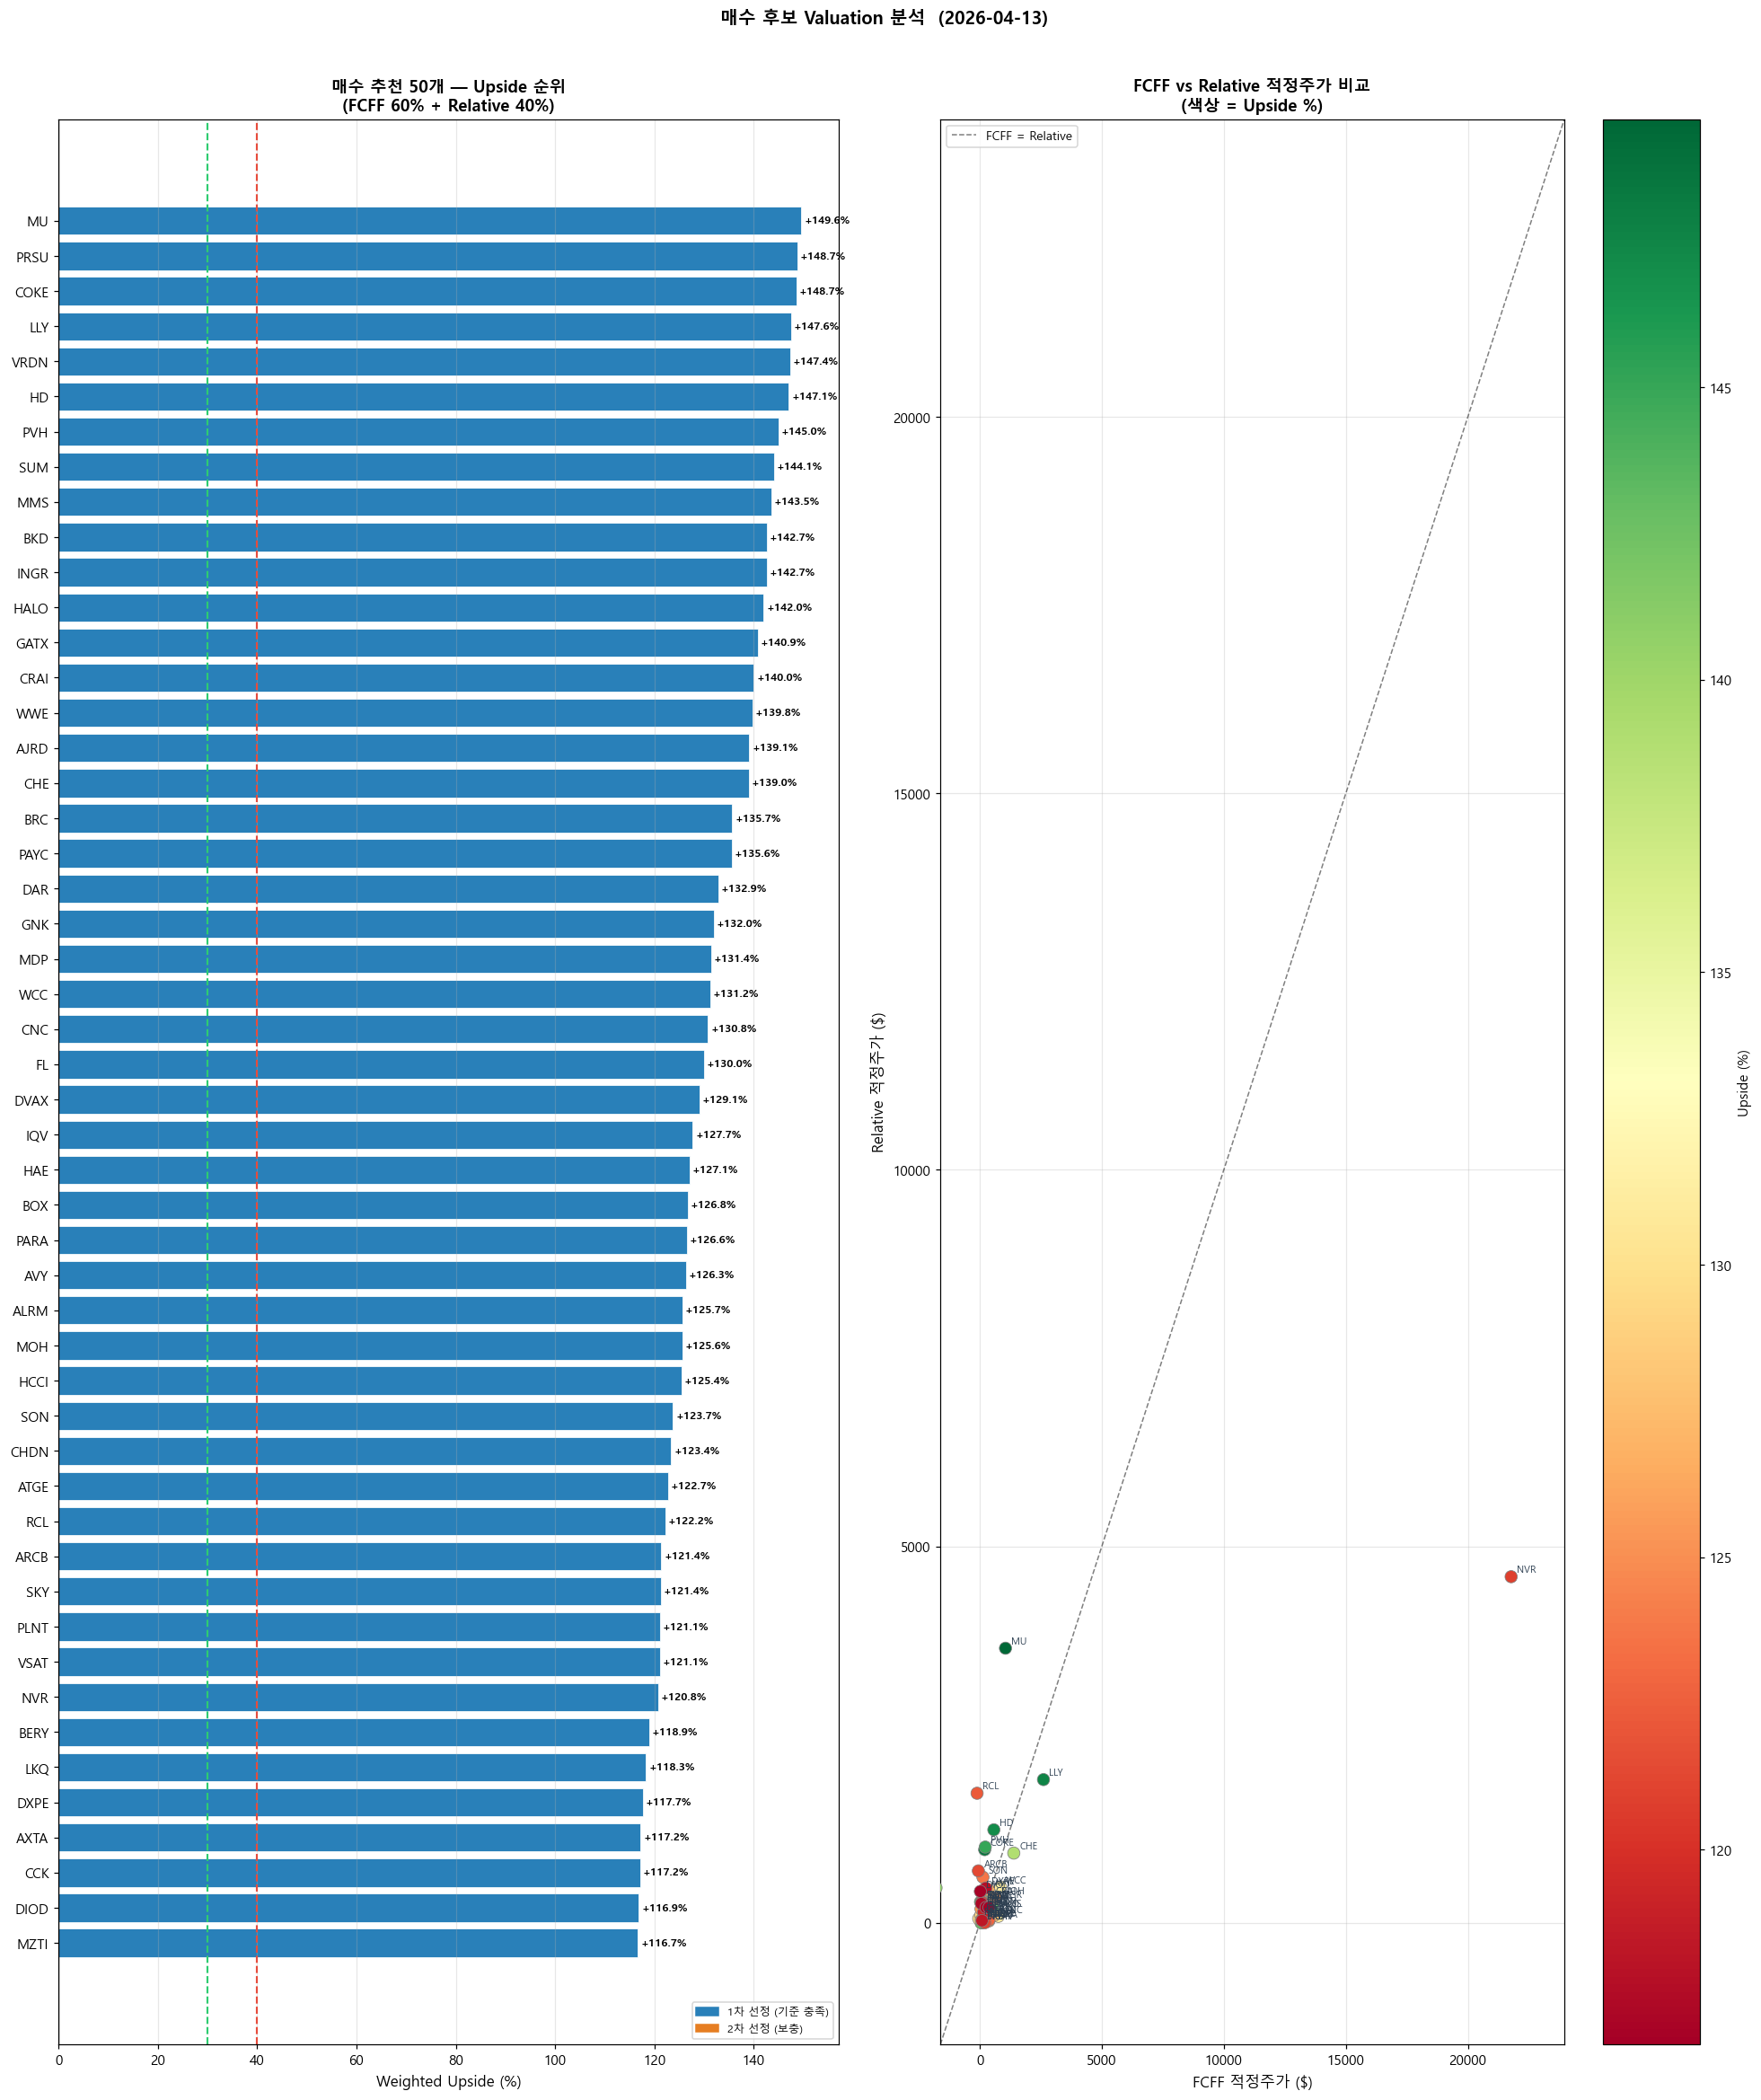

In [16]:
if df_final.empty or 'upside_weighted' not in df_final.columns:
    print('[SKIP] 시각화할 데이터 없음')
else:
    fig, axes = plt.subplots(1, 2, figsize=(18, max(6, len(df_final) * 0.42)))

    # ── [좌] Upside 순위 가로 막대 ───────────────────────────
    ax1 = axes[0]
    tickers = df_final['ticker'].tolist()[::-1]          # 위에서 아래 → 1위가 위
    upsides = df_final['upside_weighted'].tolist()[::-1]
    tiers   = df_final['selection_tier'].tolist()[::-1]  if 'selection_tier' in df_final.columns else ['']*len(tickers)

    bar_colors = [
        '#2980B9' if '1차' in str(t) else '#E67E22'
        for t in tiers
    ]

    bars = ax1.barh(tickers, upsides, color=bar_colors, edgecolor='white', linewidth=0.5)

    # 기준선
    ax1.axvline(UPSIDE_LARGE_CAP * 100, color='#2ECC71', linestyle='--',
                linewidth=1.4, label=f'대형주 기준 {UPSIDE_LARGE_CAP*100:.0f}%')
    ax1.axvline(UPSIDE_SMALL_CAP * 100, color='#E74C3C', linestyle='--',
                linewidth=1.4, label=f'중소형주 기준 {UPSIDE_SMALL_CAP*100:.0f}%')
    ax1.axvline(0, color='black', linewidth=0.8)

    # 값 레이블
    for bar, val in zip(bars, upsides):
        if pd.notna(val):
            ax1.text(
                val + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:+.1f}%',
                va='center', ha='left', fontsize=8, fontweight='bold'
            )

    ax1.set_xlabel('Weighted Upside (%)', fontsize=11)
    ax1.set_title(f'매수 추천 {len(df_final)}개 — Upside 순위\n'
                  f'(FCFF {W_FCFF*100:.0f}% + Relative {W_RELV*100:.0f}%)',
                  fontsize=12, fontweight='bold')
    ax1.legend(fontsize=9, loc='lower right')
    ax1.grid(True, axis='x', alpha=0.3)

    # 범례 설명
    from matplotlib.patches import Patch
    legend_patches = [
        Patch(color='#2980B9', label='1차 선정 (기준 충족)'),
        Patch(color='#E67E22', label='2차 선정 (보충)'),
    ]
    ax1.legend(handles=legend_patches + ax1.get_legend_handles_labels()[0][2:],
               fontsize=8, loc='lower right')

    # ── [우] FCFF vs Relative 적정주가 비교 산점도 ───────────
    ax2 = axes[1]

    has_both = df_final[df_final['model_used']=='FCFF+Rel'] if 'model_used' in df_final.columns else pd.DataFrame()

    if not has_both.empty and 'tp_fcff' in has_both.columns and 'tp_relv' in has_both.columns:
        sc = ax2.scatter(
            has_both['tp_fcff'], has_both['tp_relv'],
            c=has_both['upside_weighted'], cmap='RdYlGn',
            s=80, edgecolors='gray', linewidths=0.5, zorder=3
        )
        plt.colorbar(sc, ax=ax2, label='Upside (%)')

        # 45도 대각선 (FCFF = Relative)
        lims = [
            min(has_both['tp_fcff'].min(), has_both['tp_relv'].min()) * 0.9,
            max(has_both['tp_fcff'].max(), has_both['tp_relv'].max()) * 1.1,
        ]
        ax2.plot(lims, lims, 'k--', linewidth=1, alpha=0.5, label='FCFF = Relative')
        ax2.set_xlim(lims); ax2.set_ylim(lims)

        # 티커 레이블
        for _, row in has_both.iterrows():
            ax2.annotate(
                row['ticker'],
                (row['tp_fcff'], row['tp_relv']),
                textcoords='offset points', xytext=(4, 3),
                fontsize=7, color='#2C3E50'
            )
        ax2.set_xlabel('FCFF 적정주가 ($)', fontsize=11)
        ax2.set_ylabel('Relative 적정주가 ($)', fontsize=11)
        ax2.set_title('FCFF vs Relative 적정주가 비교\n(색상 = Upside %)', fontsize=12, fontweight='bold')
        ax2.legend(fontsize=9)
        ax2.grid(True, alpha=0.3)
    else:
        ax2.text(0.5, 0.5, '두 모형 모두 있는\n종목이 없습니다',
                 ha='center', va='center', transform=ax2.transAxes, fontsize=13)
        ax2.set_title('FCFF vs Relative 비교', fontsize=12)

    plt.suptitle(f'매수 후보 Valuation 분석  ({EVAL_DATE})', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

## Cell 8 · Excel 보고서 저장

In [17]:
# ──────────────────────────────────────────────────────────────
# Excel 시트 구성
#  1) 매수후보_랭킹    — 최종 추천 20개 (1차/2차 구분)
#  2) 전체_Valuation   — 전체 Valuation 결과 (upside 순)
#  3) FCFF_상세        — FCFF 계산 근거
#  4) Relative_상세    — PBR/PSR/PER 이론값 계산 근거
#  5) Revenue_성장률   — 4Q / 8Q 매출 성장률
# ──────────────────────────────────────────────────────────────
try:
    import openpyxl
    from openpyxl.styles import Font, PatternFill, Alignment
    from openpyxl.utils import get_column_letter
    OPENPYXL_OK = True
except ImportError:
    print('[WARN] openpyxl 없음.  pip install openpyxl')
    OPENPYXL_OK = False

if OPENPYXL_OK:
    writer = pd.ExcelWriter(REPORT_FILE, engine='openpyxl')

    def _write_sheet(df: pd.DataFrame, sheet: str):
        if df is None or df.empty:
            pd.DataFrame({'메시지': ['데이터 없음']}).to_excel(writer, sheet_name=sheet, index=False)
            return
        df.to_excel(writer, sheet_name=sheet, index=True)

    # 1) 매수 후보 랭킹
    _write_sheet(df_final[show_cols], '매수후보_랭킹')

    # 2) 전체 Valuation (upside 내림차순)
    all_val_cols = [
        'ticker', 'sector', 'mktCap_B', 'current_price',
        'tp_fcff', 'upside_fcff', 'tp_relv', 'upside_relv',
        'tp_weighted', 'upside_weighted', 'model_used', 'growth_4q',
    ]
    all_val_cols = [c for c in all_val_cols if c in df_val.columns]
    _write_sheet(
        df_val[all_val_cols].sort_values('upside_weighted', ascending=False),
        '전체_Valuation'
    )

    # 3) FCFF 상세
    fcff_detail = [
        'ticker', 'date_fcff', 'wacc', 'roic', 'g_terminal',
        'opm_forecast', 'tax_rate', 'reinvestment_rate', 'fcff',
        'enterprise_value', 'net_debt', 'equity_value', 'shares',
        'tp_fcff', 'current_price', 'upside_fcff',
    ]
    fcff_detail = [c for c in fcff_detail if c in df_val.columns]
    _write_sheet(
        df_val[fcff_detail].dropna(subset=['tp_fcff']).sort_values('upside_fcff', ascending=False),
        'FCFF_상세'
    )

    # 4) Relative 상세
    relv_detail = [
        'ticker', 'sector', 'roe_y1', 'roe_y2', 'g_est', 're_mid', 'beta_ensemble',
        'pbr_theory', 'psr_theory', 'per_theory',
        'tp_pbr', 'tp_psr', 'tp_per', 'tp_relv', 'current_price', 'upside_relv',
    ]
    relv_detail = [c for c in relv_detail if c in df_val.columns]
    _write_sheet(
        df_val[relv_detail].dropna(subset=['tp_relv']).sort_values('upside_relv', ascending=False),
        'Relative_상세'
    )

    # 5) Revenue 성장률
    if not df_rev.empty:
        _write_sheet(df_rev.sort_values('growth_4q', ascending=False), 'Revenue_성장률')

    # ── 헤더 스타일 적용 ─────────────────────────────────────
    header_fill = PatternFill('solid', fgColor='1F4E79')
    header_font = Font(color='FFFFFF', bold=True, size=10)

    for sheetname in writer.sheets:
        ws = writer.sheets[sheetname]
        for cell in ws[1]:   # 1행 = 헤더
            cell.fill      = header_fill
            cell.font      = header_font
            cell.alignment = Alignment(horizontal='center')
        # 열 너비 자동 조정 (최대 30)
        for col_cells in ws.columns:
            max_len = max(
                (len(str(c.value)) if c.value is not None else 0 for c in col_cells),
                default=8
            )
            ws.column_dimensions[get_column_letter(col_cells[0].column)].width = min(max_len + 2, 30)

    writer.close()
    print(f'[OK] Excel 보고서 저장 완료')
    print(f'     파일: {REPORT_FILE}')
    print(f'     시트: 매수후보_랭킹 / 전체_Valuation / FCFF_상세 / Relative_상세 / Revenue_성장률')
else:
    print('[SKIP] openpyxl 미설치로 Excel 저장 생략')

[OK] Excel 보고서 저장 완료
     파일: C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\reports\fundamental_report_2026-04-13.xlsx
     시트: 매수후보_랭킹 / 전체_Valuation / FCFF_상세 / Relative_상세 / Revenue_성장률


In [9]:
df_final

,ticker,date_fcff,tp_fcff,price_fcff,upside_fcff,roic,wacc,g_terminal,enterprise_value,net_debt,...,upside_weighted,upside_capped,model_used,mktCap_B,growth_4q,growth_8q,upside_min,upside_pct_dec,meets_criteria,selection_tier
1,MU,2026-04-10,1052.013165,421.51000,149.582018,1.831231,0.169645,0.040000,1.197553e+12,-1.742000e+09,...,149.582018,False,FCFF+Rel,474.31,147.695282,292.940855,0.3,1.495820,True,1차 (기준 충족)
2,DG,2026-04-10,322.459773,115.55000,179.065143,0.699573,0.056933,0.040000,8.594405e+10,1.458016e+10,...,148.899762,False,FCFF+Rel,25.49,6.041071,12.270399,0.3,1.488998,True,1차 (기준 충족)
3,SCS,2026-04-11,13.997812,16.14000,-13.272540,2.462939,0.115411,0.040000,2.073639e+09,4.037000e+08,...,148.822796,False,FCFF+Rel,1.85,3.075005,5.295423,0.4,1.488228,True,1차 (기준 충족)
4,PRSU,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,148.724984,False,Rel only,1.17,-169.254491,-42.925472,0.4,1.487250,True,1차 (기준 충족)
5,TOL,2026-04-10,361.898725,139.35000,159.704862,0.125951,0.115612,0.040000,3.657587e+10,1.651191e+09,...,148.362650,False,FCFF+Rel,13.28,8.691193,15.188594,0.3,1.483626,True,1차 (기준 충족)
6,DECK,2026-04-10,342.604540,108.64000,215.357640,24.196162,0.142035,0.040000,4.868821e+10,-1.743864e+09,...,148.352547,False,FCFF+Rel,15.72,13.298403,26.921738,0.3,1.483525,True,1차 (기준 충족)
7,VRDN,2026-04-11,61.628237,14.95000,312.229012,0.001921,0.119739,0.000000,5.064592e+09,-1.616890e+08,...,147.367832,False,FCFF+Rel,1.27,-2.956748,132.163498,0.4,1.473678,True,1차 (기준 충족)
8,FIZZ,2026-04-11,87.057905,34.71000,150.815054,1.300229,0.095821,0.040000,7.901236e+09,-2.513020e+08,...,146.354769,False,FCFF+Rel,3.25,-1.859593,-1.094163,0.4,1.463548,True,1차 (기준 충족)
9,WLFC,2026-04-11,-8805.342642,202.98000,-4438.034605,0.218878,0.045957,0.035957,-5.944364e+10,2.695667e+09,...,146.276701,False,FCFF+Rel,1.38,11.396092,31.741681,0.4,1.462767,True,1차 (기준 충족)
10,COLL,2026-04-11,1597.691077,35.47000,4404.344733,55.479734,0.066052,0.040000,6.412050e+10,6.894570e+08,...,146.255175,False,FCFF+Rel,1.13,12.782756,29.856247,0.4,1.462552,True,1차 (기준 충족)
